In [86]:
import ase.io
import numpy as np
import matplotlib.pyplot

In [87]:
target_atoms = ase.io.read("/home/tuoping/odefed_mdgen//workdir_odefed_mdgen/data/MP_C_data/conventional.extxyz", ":")[4]
print(target_atoms.get_cell())

Cell([4.5760164, 4.582040239999996, 13.10660406])


In [88]:
target_atoms.wrap()
target_frac_pos = target_atoms.get_scaled_positions()
print(target_frac_pos)

[[0.25       0.43504562 0.375     ]
 [0.25       0.06495438 0.125     ]
 [0.         0.18504562 0.375     ]
 [0.         0.31495438 0.125     ]
 [0.25       0.43504562 0.875     ]
 [0.25       0.06495438 0.625     ]
 [0.         0.18504562 0.875     ]
 [0.         0.31495438 0.625     ]
 [0.25       0.93504562 0.375     ]
 [0.25       0.56495438 0.125     ]
 [0.         0.68504562 0.375     ]
 [0.         0.81495438 0.125     ]
 [0.25       0.93504562 0.875     ]
 [0.25       0.56495438 0.625     ]
 [0.         0.68504562 0.875     ]
 [0.         0.81495438 0.625     ]
 [0.75       0.43504562 0.375     ]
 [0.75       0.06495438 0.125     ]
 [0.5        0.18504562 0.375     ]
 [0.5        0.31495438 0.125     ]
 [0.75       0.43504562 0.875     ]
 [0.75       0.06495438 0.625     ]
 [0.5        0.18504562 0.875     ]
 [0.5        0.31495438 0.625     ]
 [0.75       0.93504562 0.375     ]
 [0.75       0.56495438 0.125     ]
 [0.5        0.68504562 0.375     ]
 [0.5        0.81495438 0.12

In [89]:
from ase.visualize import view
view(target_atoms, viewer='ngl')

In [90]:
import torch
import scipy
import math

def lattice_polar_decompose(lattice: np.ndarray):
    assert lattice.ndim == 2
    A, U = np.linalg.eigh(lattice @ lattice.T)
    A, U = np.real(A), np.real(U)
    A = np.diag(np.log(A)) / 2
    S = U @ A @ U.T

    k = np.array(
        [
            S[0, 1],
            S[0, 2],
            S[1, 2],
            (S[0, 0] - S[1, 1]) / 2,
            (S[0, 0] + S[1, 1] - 2 * S[2, 2]) / 6,
            (S[0, 0] + S[1, 1] + S[2, 2]) / 3,
        ]
    )
    return k

def lattice_polar_build(k: np.ndarray):
    assert k.ndim == 1
    S = np.array(
        [
            [k[3] + k[4] + k[5], k[0], k[1]],
            [k[0], -k[3] + k[4] + k[5], k[2]],
            [k[1], k[2], -2 * k[4] + k[5]],
        ]
    )  # (3, 3)
    expS = scipy.linalg.expm(S)  # (3, 3)
    return expS


def decompose_symmetric_matrix(S: torch.Tensor):
    k0 = S[:, 0, 1]
    k1 = S[:, 0, 2]
    k2 = S[:, 1, 2]
    k3 = (S[:, 0, 0] - S[:, 1, 1]) / 2
    k4 = (S[:, 0, 0] + S[:, 1, 1] - 2 * S[:, 2, 2]) / 6
    k5 = (S[:, 0, 0] + S[:, 1, 1] + S[:, 2, 2]) / 3
    k = torch.vstack([k0, k1, k2, k3, k4, k5]).transpose(-1, -2)
    return k


@torch.no_grad()
def lattice_polar_decompose_torch(lattices: torch.Tensor):
    assert lattices.dim() == 3, "input must be batched lattices of shape (B,3,3)"
    A, U = torch.linalg.eigh(lattices @ lattices.transpose(-1,-2))  # J = L^T @ L
    # S = 1/2 U log(A) U^T
    A = torch.diag_embed(A.log()) / 2
    S = U @ A @ U.transpose(-1, -2)
    k = decompose_symmetric_matrix(S)
    return k

@torch.no_grad()
def lattice_polar_build_torch(k):
    assert k.dim() == 2, "input must be batched k of shape (B,6)"
    S0 = torch.stack([k[:, 3] + k[:, 4] + k[:, 5], k[:, 0], k[:, 1]], dim=1)  # (B, 3)
    S1 = torch.stack([k[:, 0], -k[:, 3] + k[:, 4] + k[:, 5], k[:, 2]], dim=1)  # (B, 3)
    S2 = torch.stack([k[:, 1], k[:, 2], -2 * k[:, 4] + k[:, 5]], dim=1)  # (B, 3)
    S = torch.stack([S0, S1, S2], dim=1)  # (B, 3, 3)
    expS = torch.matrix_exp(S)  # (B, 3, 3)
    return expS


def get_reciprocal_lattice_torch(L):
    V = torch.det(L)[:, None] + 1e-9  # (B, 1)
    a0 = L[:, 0, :]  # (B, 3)
    a1 = L[:, 1, :]
    a2 = L[:, 2, :]
    cross_a12 = torch.cross(a1, a2, dim=1)  # (B, 3)
    cross_a20 = torch.cross(a2, a0, dim=1)
    cross_a01 = torch.cross(a0, a1, dim=1)
    b0 = (2 * math.pi * cross_a12 / V)[:, None, :]  # (B, 1, 3)
    b1 = (2 * math.pi * cross_a20 / V)[:, None, :]  # (B, 1, 3)
    b2 = (2 * math.pi * cross_a01 / V)[:, None, :]  # (B, 1, 3)
    b = torch.cat([b0, b1, b2], dim=1)  # (B, 3, 3)
    return b

In [91]:
import torch
from ase import Atoms
target_cell = lattice_polar_decompose(target_atoms.get_cell())

_check_target_cell = lattice_polar_build(target_cell)
print(target_atoms.get_cell())
print(_check_target_cell)
_atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _check_target_cell,
        pbc=[True, True, True]
)

# print(target_atoms.get_cell_lengths_and_angles(), _atoms.get_cell_lengths_and_angles())
from ase.visualize import view
view(_atoms, viewer='ngl')

Cell([4.5760164, 4.582040239999996, 13.10660406])
[[ 4.5760164   0.          0.        ]
 [ 0.          4.58204024  0.        ]
 [ 0.          0.         13.10660406]]


In [92]:
import torch
def sample_prior_cell():
    mu = torch.zeros(6)
    mu[-1] = 1.
    sigma = 0.1
    cell = torch.normal(mu, sigma)
    return cell
prior_cell = sample_prior_cell()
print(prior_cell)

tensor([ 0.0781,  0.0762,  0.0107, -0.0365,  0.0347,  0.8296])


In [93]:
t = torch.range(0,1,0.02)
print(t)

tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800, 0.2000, 0.2200, 0.2400, 0.2600, 0.2800, 0.3000, 0.3200, 0.3400,
        0.3600, 0.3800, 0.4000, 0.4200, 0.4400, 0.4600, 0.4800, 0.5000, 0.5200,
        0.5400, 0.5600, 0.5800, 0.6000, 0.6200, 0.6400, 0.6600, 0.6800, 0.7000,
        0.7200, 0.7400, 0.7600, 0.7800, 0.8000, 0.8200, 0.8400, 0.8600, 0.8800,
        0.9000, 0.9200, 0.9400, 0.9600, 0.9800, 1.0000])


/tmp/ipykernel_2067606/2795543798.py:1: UserWarning: torch.range is deprecated and will be removed in a future release because its behavior is inconsistent with Python's range builtin. Instead, use torch.arange, which produces values in [start, end).
  t = torch.range(0,1,0.02)


## Rectified flow of lattice

In [94]:
target_cell = torch.from_numpy(target_cell)
ut_cell = target_cell - prior_cell
xt_cell = t[:,None]*target_cell + (1-t[:,None])* prior_cell
print(xt_cell)
print(xt_cell.shape)

tensor([[ 7.8063e-02,  7.6223e-02,  1.0725e-02, -3.6490e-02,  3.4700e-02,
          8.2964e-01],
        [ 7.6502e-02,  7.4699e-02,  1.0511e-02, -3.5773e-02,  2.6995e-02,
          8.5048e-01],
        [ 7.4940e-02,  7.3174e-02,  1.0296e-02, -3.5056e-02,  1.9291e-02,
          8.7133e-01],
        [ 7.3379e-02,  7.1650e-02,  1.0082e-02, -3.4340e-02,  1.1586e-02,
          8.9218e-01],
        [ 7.1818e-02,  7.0125e-02,  9.8672e-03, -3.3623e-02,  3.8809e-03,
          9.1303e-01],
        [ 7.0257e-02,  6.8601e-02,  9.6527e-03, -3.2906e-02, -3.8240e-03,
          9.3388e-01],
        [ 6.8695e-02,  6.7076e-02,  9.4382e-03, -3.2190e-02, -1.1529e-02,
          9.5472e-01],
        [ 6.7134e-02,  6.5552e-02,  9.2237e-03, -3.1473e-02, -1.9234e-02,
          9.7557e-01],
        [ 6.5573e-02,  6.4027e-02,  9.0092e-03, -3.0757e-02, -2.6939e-02,
          9.9642e-01],
        [ 6.4012e-02,  6.2503e-02,  8.7947e-03, -3.0040e-02, -3.4643e-02,
          1.0173e+00],
        [ 6.2450e-02,  6.0978e

In [95]:
from ase import Atoms
_traj = []
for i in range(0, len(t), 10):
    _cell = lattice_polar_build(xt_cell[i].numpy())
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _cell,
        pbc=[True, True, True]
    )
    print(_atoms.get_cell_lengths_and_angles())
    _traj.append(_atoms)

[ 2.31589129  2.47639169  2.15227145 88.09564344 81.20870256 81.01399032]
[ 2.65021544  2.7981533   3.08414549 88.61240183 82.95242423 82.80441603]
[ 3.03449539  3.16311138  4.42416669 89.03386046 84.61421314 84.60147188]
[ 3.47670602  3.5772985   6.35108354 89.38934409 86.28118328 86.40277358]
[ 3.98651428  4.04762992  9.12197859 89.70398726 88.04393732 88.20449053]
[ 4.5760164   4.58204024 13.10660406 90.         90.         90.        ]


/tmp/ipykernel_2067606/2643556869.py:11: DeprecationWarning: Please use atoms.cell.cellpar() instead
  print(_atoms.get_cell_lengths_and_angles())


In [96]:
view(_traj[0], viewer='ngl')

In [97]:
view(_traj[4], viewer='ngl')

In [98]:
view(_traj[-1], viewer='ngl')

## Rectified flow of lattice

## Lipman flow of lattice

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2067606/1710916411.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$D=\sigma^2/2$")


Text(0, 0.5, '$D=\\sigma^2/2$')

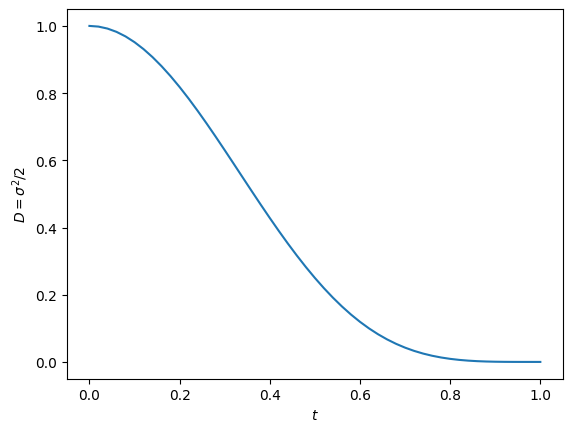

In [99]:
def expand_t_like_x(t, x):
    """Function to reshape time t to broadcastable dimension of x
    Args:
      t: [batch_dim,], time vector
      x: [batch_dim,...], data point
    """
    dims = [1] * (len(x.size()) - 1)
    t = t.view(t.size(0), *dims)
    return t


def compute_diffusion(x, t, norm=1.0):
    # return norm*torch.sin(np.pi * t)**2                 # increasing-decreasing
    return 0.25 * (norm * torch.cos(np.pi * t) + 1) ** 2     # decreasing

diffusion_t = compute_diffusion(prior_cell, t)
import matplotlib.pyplot as plt
plt.plot(t, diffusion_t[:])
plt.xlabel("$t$")
plt.ylabel("$D=\sigma^2/2$")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2067606/4280418546.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")


Text(0, 0.5, '$\\sqrt{\\sigma^2*t(1-t)}$')

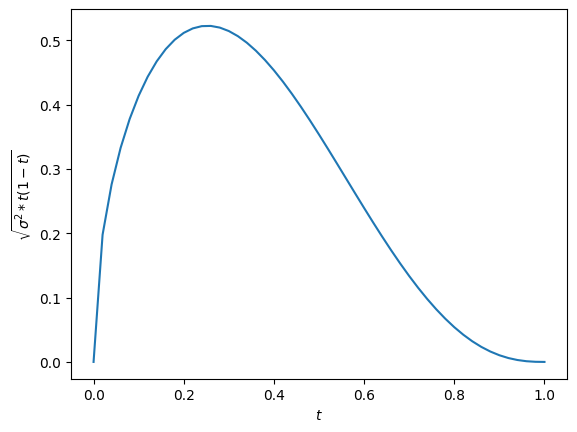

In [100]:
def compute_marginal_std(t, diffusion):
    """Compute the marginal standard deviation of the time-dependent density p_t"""
    return torch.sqrt(2*diffusion) * torch.sqrt(t*(1-t))

sigma_t = compute_marginal_std(t, diffusion_t)

plt.plot(t, sigma_t[:])
plt.xlabel("$t$")
plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")

In [101]:

# target_cell = torch.from_numpy(target_cell)
mu_t_cell = t[:,None]*target_cell + (1-t[:,None])* prior_cell
std_t = expand_t_like_x(sigma_t, mu_t_cell)

epsilon = torch.randn_like(mu_t_cell)
xt_cell = mu_t_cell + std_t*epsilon
print(xt_cell)
print(xt_cell.shape)

tensor([[ 7.8063e-02,  7.6223e-02,  1.0725e-02, -3.6490e-02,  3.4700e-02,
          8.2964e-01],
        [ 2.0292e-01,  2.8019e-01,  6.7151e-02, -1.1381e-01, -4.0861e-01,
          8.7786e-01],
        [ 4.7720e-02,  2.1372e-01, -1.6372e-02, -2.2724e-01, -1.2733e-01,
          9.3371e-01],
        [ 2.9666e-01,  4.6489e-01, -4.7471e-01, -4.8589e-01, -8.8619e-02,
          1.1014e+00],
        [ 4.8632e-04,  8.8181e-01,  4.1442e-01,  3.0769e-01,  2.5376e-01,
          8.4528e-01],
        [ 3.8108e-01,  2.1782e-01, -4.4113e-01, -1.1212e+00, -5.0100e-03,
          7.3044e-01],
        [-3.4914e-01, -1.4423e-01, -4.5630e-01,  6.2548e-01,  6.0033e-01,
          1.2763e+00],
        [-3.2510e-02, -1.1609e-01, -1.3874e-01,  5.9993e-01, -6.3134e-02,
         -5.8067e-02],
        [-1.2895e-01,  5.7461e-02,  2.9306e-01, -2.8405e-01, -4.2536e-01,
          7.1100e-01],
        [ 1.9033e-01,  1.6190e-01,  5.0299e-01, -1.3571e-01,  3.0805e-01,
          1.5855e+00],
        [-2.3672e-02,  5.5044e

In [102]:
from ase import Atoms
_traj = []
_traj_lattice_constants = []
for i in range(0, len(t), 10):
    _cell = lattice_polar_build(xt_cell[i].numpy())
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = target_frac_pos,
        cell = _cell,
        pbc=[True, True, True]
    )
    print(_atoms.get_cell_lengths_and_angles())
    _traj_lattice_constants.append(_atoms.get_cell_lengths_and_angles())
    _traj.append(_atoms)

[ 2.31589129  2.47639169  2.15227145 88.09564344 81.20870256 81.01399032]
[ 15.51111838   1.4447675    5.11528363 113.73003469  26.71981043
 107.42305398]
[  2.40155478   1.48659282   3.85784919 120.36536949  61.74568997
 107.62222818]
[  4.29837327   2.73812769   5.99682357 111.00218277  83.4718258
  64.50260571]
[ 4.04298317  4.57331223  7.39350677 91.61212678 94.82382346 74.89285334]
[ 4.5760164   4.58204024 13.10660406 90.         90.         90.        ]


/tmp/ipykernel_2067606/1106380275.py:12: DeprecationWarning: Please use atoms.cell.cellpar() instead
  print(_atoms.get_cell_lengths_and_angles())
/tmp/ipykernel_2067606/1106380275.py:13: DeprecationWarning: Please use atoms.cell.cellpar() instead
  _traj_lattice_constants.append(_atoms.get_cell_lengths_and_angles())


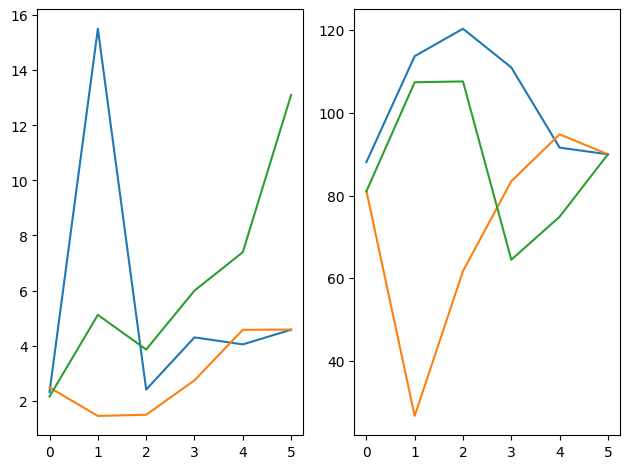

In [103]:
_traj_lattice_constants = np.array(_traj_lattice_constants)
plt.subplot(121)
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,0])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,1])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,2])
plt.subplot(122)
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,3])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,4])
plt.plot(np.arange(len(_traj_lattice_constants)), _traj_lattice_constants[:,5])
plt.tight_layout()

In [104]:
view(_traj[5], viewer='ngl')

# Flow of fractional coordinates

In [105]:
def sample_prior_frac_pos(N):
    mu = torch.zeros(N*3)
    sigma = 1.
    pos = torch.rand(mu.shape)
    return pos
prior_frac_pos = sample_prior_frac_pos(target_atoms.get_number_of_atoms())
print(prior_frac_pos)

tensor([0.6945, 0.2641, 0.4957, 0.2804, 0.6487, 0.2300, 0.1981, 0.5441, 0.6385,
        0.8225, 0.2454, 0.4608, 0.4424, 0.6717, 0.7991, 0.0389, 0.3443, 0.2965,
        0.2930, 0.4871, 0.6828, 0.7470, 0.4990, 0.6501, 0.0863, 0.0642, 0.7952,
        0.5783, 0.1983, 0.7038, 0.3479, 0.8570, 0.2883, 0.9774, 0.8371, 0.3537,
        0.8867, 0.3167, 0.1648, 0.5234, 0.6512, 0.5883, 0.3986, 0.3666, 0.3647,
        0.7918, 0.7385, 0.0965, 0.5344, 0.7372, 0.5852, 0.1400, 0.0737, 0.5409,
        0.7038, 0.1111, 0.1449, 0.3542, 0.4482, 0.8197, 0.5756, 0.2278, 0.0582,
        0.5562, 0.9472, 0.4347, 0.4815, 0.3492, 0.9519, 0.8155, 0.9948, 0.7197,
        0.4926, 0.6783, 0.6983, 0.4117, 0.0322, 0.5074, 0.1387, 0.6559, 0.1595,
        0.9301, 0.7872, 0.4871, 0.1314, 0.1267, 0.8525, 0.4700, 0.0139, 0.7408,
        0.9815, 0.4155, 0.6994, 0.6692, 0.0217, 0.0261])


/tmp/ipykernel_2067606/155833395.py:6: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  prior_frac_pos = sample_prior_frac_pos(target_atoms.get_number_of_atoms())


In [106]:
def wrap_frac_pos(F):
    return F-(F).to(int)
target_frac_pos = torch.from_numpy(target_frac_pos)
prior_frac_pos = wrap_frac_pos(prior_frac_pos.reshape(-1,3))

## Rectified flow

In [107]:
print(prior_frac_pos.shape)
print(target_frac_pos.shape)
print(t.shape)

torch.Size([32, 3])
torch.Size([32, 3])
torch.Size([51])


In [108]:

xt_frac_pos = (prior_frac_pos[None,:,:] + t[:,None,None]*(wrap_frac_pos(target_frac_pos - prior_frac_pos - 0.5)[None,:,:] - 0.5))
print(xt_frac_pos)
print(xt_frac_pos.shape)

tensor([[[ 0.6945,  0.2641,  0.4957],
         [ 0.2804,  0.6487,  0.2300],
         [ 0.1981,  0.5441,  0.6385],
         ...,
         [ 0.4700,  0.0139,  0.7408],
         [ 0.9815,  0.4155,  0.6994],
         [ 0.6692,  0.0217,  0.0261]],

        [[ 0.6656,  0.2475,  0.4732],
         [ 0.2598,  0.6370,  0.2079],
         [ 0.1742,  0.5169,  0.6132],
         ...,
         [ 0.4556,  0.0049,  0.7185],
         [ 0.9519,  0.4009,  0.6829],
         [ 0.6458,  0.0176,  0.0181]],

        [[ 0.6368,  0.2309,  0.4508],
         [ 0.2392,  0.6253,  0.1858],
         [ 0.1502,  0.4898,  0.5879],
         ...,
         [ 0.4412, -0.0041,  0.6962],
         [ 0.9223,  0.3863,  0.6664],
         [ 0.6224,  0.0134,  0.0101]],

        ...,

        [[-0.6922, -0.5318, -0.5802],
         [-0.7088,  0.0883, -0.8308],
         [-0.9521, -0.7606, -0.5745],
         ...,
         [-0.2212, -0.4171, -0.3304],
         [-0.4407, -0.2857, -0.0920],
         [-0.4532, -0.1768, -0.3590]],

        [[

In [109]:
_traj = []
for i in range(0, len(t), 10):
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = xt_frac_pos[i].numpy(),
        cell = target_atoms.get_cell(),
        pbc=[True,True,True]
    )
    _atoms.wrap()
    _traj.append(_atoms)

In [110]:
view(_traj[0], viewer='ngl')

In [111]:
view(_traj[3], viewer='ngl')

In [112]:
view(_traj[5], viewer='ngl')

## Lipman flow

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2067606/1445051594.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$D=\sigma^2/2$")


Text(0, 0.5, '$D=\\sigma^2/2$')

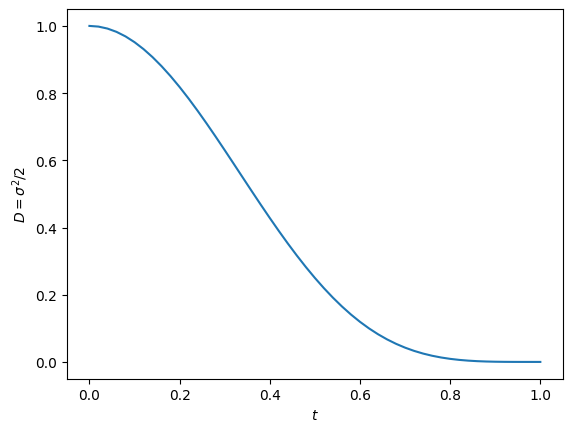

In [113]:
def expand_t_like_x(t, x):
    """Function to reshape time t to broadcastable dimension of x
    Args:
      t: [batch_dim,], time vector
      x: [batch_dim,...], data point
    """
    dims = [1] * (len(x.size()) - 1)
    t = t.view(t.size(0), *dims)
    return t


def compute_diffusion(x, t, norm=1.0):
    # return norm*torch.sin(np.pi * t)**2                 # increasing-decreasing
    return 0.25 * (norm * torch.cos(np.pi * t) + 1) ** 2     # decreasing

diffusion_t = compute_diffusion(prior_frac_pos, t)
import matplotlib.pyplot as plt
plt.plot(t, diffusion_t[:])
plt.xlabel("$t$")
plt.ylabel("$D=\sigma^2/2$")

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2067606/4280418546.py:9: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")


Text(0, 0.5, '$\\sqrt{\\sigma^2*t(1-t)}$')

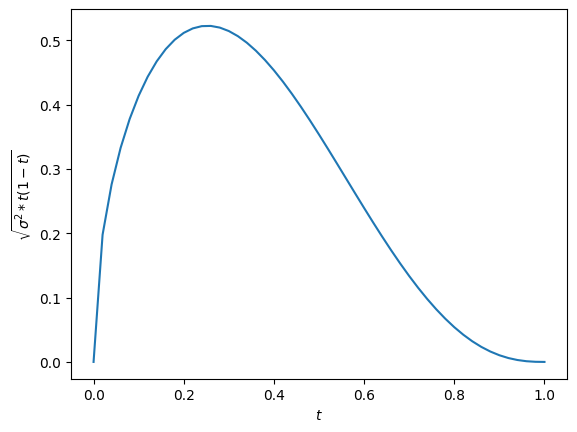

In [114]:
def compute_marginal_std(t, diffusion):
    """Compute the marginal standard deviation of the time-dependent density p_t"""
    return torch.sqrt(2*diffusion) * torch.sqrt(t*(1-t))

sigma_t = compute_marginal_std(t, diffusion_t)

plt.plot(t, sigma_t[:])
plt.xlabel("$t$")
plt.ylabel("$\sqrt{\sigma^2*t(1-t)}$")

In [115]:
def ewald_wrap_frac_pos(F):
    pass

In [116]:

mu_t_frac_pos = (prior_frac_pos[None,:,:] + t[:,None,None]*(wrap_frac_pos(target_frac_pos - prior_frac_pos - 0.5)[None,:,:] - 0.5))
std_t = expand_t_like_x(sigma_t, mu_t_frac_pos)

epsilon = torch.randn_like(mu_t_frac_pos)
xt_frac_pos = mu_t_frac_pos + std_t*epsilon
print(xt_frac_pos)
print(xt_frac_pos.shape)

tensor([[[ 0.6945,  0.2641,  0.4957],
         [ 0.2804,  0.6487,  0.2300],
         [ 0.1981,  0.5441,  0.6385],
         ...,
         [ 0.4700,  0.0139,  0.7408],
         [ 0.9815,  0.4155,  0.6994],
         [ 0.6692,  0.0217,  0.0261]],

        [[ 0.7253,  0.1787,  0.5519],
         [-0.1402,  0.7774,  0.4556],
         [-0.0902,  0.1039,  0.8049],
         ...,
         [ 0.2945,  0.2104,  0.8164],
         [ 1.0547,  0.3327,  0.5761],
         [ 0.8589, -0.0906,  0.0885]],

        [[ 0.6389,  0.3203,  0.5588],
         [ 0.2298,  0.5253,  0.0848],
         [ 0.0604,  0.2399,  0.6569],
         ...,
         [ 0.5278, -0.1712,  0.7491],
         [ 1.3610, -0.4492,  0.6765],
         [ 1.3736,  0.0843,  0.1118]],

        ...,

        [[-0.6915, -0.5316, -0.5797],
         [-0.7089,  0.0883, -0.8308],
         [-0.9523, -0.7594, -0.5733],
         ...,
         [-0.2220, -0.4174, -0.3296],
         [-0.4409, -0.2887, -0.0931],
         [-0.4536, -0.1766, -0.3567]],

        [[

In [117]:
_traj = []
for i in range(0, len(t), 10):
    _atoms = Atoms(
        target_atoms.get_chemical_symbols(),
        scaled_positions = xt_frac_pos[i].numpy(),
        cell = target_atoms.get_cell(),
        pbc=[True,True,True]
    )
    # _atoms.wrap()
    _traj.append(_atoms)

In [118]:
view(_traj[3], viewer='ngl')

In [119]:
view(_traj[5], viewer='ngl')